In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,KGMultiModalPerceiver
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('NACC_normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'NACC_nii_no/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('NACC_ad.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'NACC_nii_ad/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('NACC_mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'NACC_mci/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #44
print(count_no) #247
print(count_mci) #106

713
2116
879


In [3]:
ad_arrays=[]
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','no':'0','yes':'1','ans':'2','haw':'3','ind':'4'}
for i in data_ad:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    ad_array = np.array(num_list)
    ad_arrays.append(ad_array)
ad_array = np.vstack(ad_arrays)
normal_arrays=[]
for i in data_normal:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    normal_array = np.array(num_list)
    normal_arrays.append(normal_array)
normal_array = np.vstack(normal_arrays)
mci_arrays=[]
for i in data_mci:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    mci_array = np.array(num_list)
    mci_arrays.append(mci_array)
mci_array = np.vstack(mci_arrays)

In [4]:
#加权算值
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [5]:
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()
print(ad_tensor.shape)

normal_labels = torch.zeros(normal_tensor.shape[0], dtype=torch.long)
mci_labels = torch.ones(mci_tensor.shape[0], dtype=torch.long)
ad_labels = torch.full((ad_tensor.shape[0],), 2, dtype=torch.long)

X = torch.cat([ad_tensor, normal_tensor, mci_tensor], dim=0)
y = torch.cat([ad_labels, normal_labels, mci_labels], dim=0)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
model = NeuralNet(embedding=81)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(20):
    for inputs, labels in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()        
with torch.no_grad():
    ad_tensor = model(ad_tensor)
    normal_tensor = model(normal_tensor)
    mci_tensor = model(mci_tensor)
    
ad_tensor = weighted_sum(ad_tensor)
mci_tensor = weighted_sum(mci_tensor)
normal_tensor = weighted_sum(normal_tensor)

print('AD_tensor shape:', ad_tensor.shape)
print('Normal_tensor shape:', normal_tensor.shape)
print('MCI_tensor shape:', mci_tensor.shape)

torch.Size([713, 81])
AD_tensor shape: torch.Size([713, 1])
Normal_tensor shape: torch.Size([2116, 1])
MCI_tensor shape: torch.Size([879, 1])


In [6]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[3:27])
    return np.array(processed_data)

# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [7]:
ad_data = preprocess_data(data_ad, replace_dict)
normal_data = preprocess_data(data_normal, replace_dict)
mci_data = preprocess_data(data_mci, replace_dict)

categorical_indices = [2, 3, 4, 5 ,6 ,7]  # gender, education, hispanic, race, apoe
ad_EHR = encode_categorical(ad_data, categorical_indices)
normal_EHR = encode_categorical(normal_data, categorical_indices)
mci_EHR = encode_categorical(mci_data, categorical_indices)

ad_EHR = torch.from_numpy(ad_EHR).float()
normal_EHR = torch.from_numpy(normal_EHR).float()
mci_EHR = torch.from_numpy(mci_EHR).float()

linear_layer = nn.Linear(24, 16)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

linear_layer = nn.Linear(16, 1)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

print('ad.EHR--->',ad_EHR.shape)
print('normal.EHR--->',normal_EHR.shape)
print('mci.EHR--->',mci_EHR.shape)

ad.EHR---> torch.Size([713, 1])
normal.EHR---> torch.Size([2116, 1])
mci.EHR---> torch.Size([879, 1])


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
import torch
import gc

# 1. 显式清理缓存，防止之前的残留占用显存
torch.cuda.empty_cache()
gc.collect()

# 医学图像模型初始化
nii = CNN_3D(num_class=1)
nii = nii.to(device)
# 2. 设置为评估模式 (关键)
nii.eval()

all_ad = 'NACC_nii_ad'
all_normal = 'NACC_nii_no'
all_mci = 'NACC_mci'

# 3. 减小 Batch Size (建议从 4 开始尝试，如果还爆显存改为 2 或 1)
batch_size = 4 

# --- 处理 AD ---
dataset = NiiDataset(all_ad)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []

# 4. 使用 no_grad 上下文管理器 (关键：不计算梯度)
with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        # 5. 将结果 detach 并移至 CPU，防止显存堆积
        all_outputs.append(output.detach().cpu())

# 拼接后形状处理
ad_output = torch.cat(all_outputs, dim=0)
print('ad nii shape--->', ad_output.shape)

# 清理中间变量并释放显存
del all_outputs, dataset, dataloader
torch.cuda.empty_cache()

# --- 处理 Normal ---
dataset = NiiDataset(all_normal)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []

with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        all_outputs.append(output.detach().cpu())

normal_output = torch.cat(all_outputs, dim=0)
print('normal nii shape--->', normal_output.shape)

del all_outputs, dataset, dataloader
torch.cuda.empty_cache()

# --- 处理 MCI ---
dataset = NiiDataset(all_mci)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []

with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        all_outputs.append(output.detach().cpu())

mci_output = torch.cat(all_outputs, dim=0)
print('mci nii shape--->', mci_output.shape)

ad nii shape---> torch.Size([713, 1])
normal nii shape---> torch.Size([2116, 1])
mci nii shape---> torch.Size([879, 1])


In [10]:
# ---------- DementiaKG 知识图谱 Embedding 加载与特征提取 ----------
import numpy as np
import torch
import pandas as pd
import json
import os

# 1. 加载 DementiaKG 的映射字典和特征矩阵
ENTITY2ID_JSON = 'nacc_kg_entity2id.json'
EMBED_NPY = 'nacc_kg_embeddings.npy'

with open(ENTITY2ID_JSON, 'r', encoding='utf-8') as f:
    entity2id = json.load(f)

# 自动推断维度，DementiaKG 默认为 128 维
kg_embeddings = torch.from_numpy(np.load(EMBED_NPY)).float()
embed_dim = kg_embeddings.shape[1] 

class DementiaKGExtract:
    def __init__(self, embeddings, ent2id, dim):
        self.embeddings = embeddings
        self.ent2id = ent2id
        self.dim = dim
        
        # 【新增】定义病史到 PrimeKG 节点的映射字典
        # 按照你构建图谱时 HISTORY_MAP 的逻辑和可能生成的节点名称，枚举查找
        self.history_map = {
            "his_HYPERTEN": ["PrimeKG:Hypertension", "Condition:Hypertension"],
            "his_HYPERCHO": ["PrimeKG:Hypercholesterolemia", "PrimeKG:Hyperlipidemia", "PrimeKG:Cholesterol", "Condition:Hypercholesterolemia"],
            "his_DIABETES": ["PrimeKG:Diabetes", "PrimeKG:Diabetes mellitus", "Condition:Diabetes"],
            "his_DEP2YRS":  ["PrimeKG:Depression", "PrimeKG:Depressive", "Condition:Depression"],
            "his_THYROID":  ["PrimeKG:Hypothyroidism", "PrimeKG:Thyroid", "Condition:Thyroid"],
            "his_ANXIETY":  ["PrimeKG:Anxiety", "Condition:Anxiety"]
        }

    def get_patient_embedding(self, patient_id, row_data=None):
        node_name = f"Patient:{patient_id}"
        
        patient_self_emb = None
        # 1. 提取患者自身在图谱中训练出的 Embedding (如果存在)
        if node_name in self.ent2id:
            idx = self.ent2id[node_name]
            patient_self_emb = self.embeddings[idx]
            
        neighbor_embeddings = []
        
        # 2. 收集患者所有的临床和生物学邻居节点特征
        if row_data is not None:
            # 提取基础人口学特征节点
            for col, prefix in [("age", "Concept:Age"), ("gender", "Concept:Sex"), ("education", "Concept:Education")]:
                if col in row_data and pd.notna(row_data[col]):
                    ent = f"{prefix}:{str(row_data[col])}"
                    if ent in self.ent2id:
                        neighbor_embeddings.append(self.embeddings[self.ent2id[ent]])

            # 提取 APOE 基因风险节点
            if 'apoe' in row_data and pd.notna(row_data['apoe']) and float(row_data['apoe']) == 1.0:
                ent = "Gene:APOE_e4_Carrier"
                if ent in self.ent2id:
                    neighbor_embeddings.append(self.embeddings[self.ent2id[ent]])

            # 提取认知量表测试节点
            for test_col, test_prefix in [('mmse', 'MMSE'), ('moca', 'MoCA')]:
                if test_col in row_data and pd.notna(row_data[test_col]):
                    ent = f"Test:{test_prefix}:{int(float(row_data[test_col]))}"
                    if ent in self.ent2id:
                        neighbor_embeddings.append(self.embeddings[self.ent2id[ent]])
            
            if 'cdr' in row_data and pd.notna(row_data['cdr']):
                ent = f"Test:CDR:{float(row_data['cdr'])}"
                if ent in self.ent2id:
                    neighbor_embeddings.append(self.embeddings[self.ent2id[ent]])

            # 【核心修复】将具有丰富外部知识的 PrimeKG 节点加入聚合范畴！
            for his_col, kg_nodes in self.history_map.items():
                if his_col in row_data and pd.notna(row_data[his_col]) and float(row_data[his_col]) == 1.0:
                    for kg_node in kg_nodes:
                        if kg_node in self.ent2id:
                            neighbor_embeddings.append(self.embeddings[self.ent2id[kg_node]])
                            break # 匹配到一个映射的节点就停止，找下一个病史

        # ---------------------------------------------------------
        # 3. 增强策略：混合患者自身 Embedding 与 PrimeKG 外部知识表征
        # ---------------------------------------------------------
        if patient_self_emb is not None and len(neighbor_embeddings) > 0:
            neighbor_mean = torch.stack(neighbor_embeddings).mean(dim=0)
            # 通过叠加外部知识邻居，弥补 Patient 自身节点可能欠拟合的问题
            return (patient_self_emb + neighbor_mean) / 2.0
            
        elif patient_self_emb is not None:
            # 只有自身节点，没有邻居
            return patient_self_emb
            
        elif len(neighbor_embeddings) > 0:
            # 完全未见过的测试集患者，通过 PrimeKG 及测试集特征纯归纳式聚合
            return torch.stack(neighbor_embeddings).mean(dim=0)
            
        else:
            return torch.zeros(self.dim)

# 实例化提取器
extractor = DementiaKGExtract(kg_embeddings, entity2id, embed_dim)

# 2. 读取原始的 CSV 数据
nii_folders = {
    'ad': 'NACC_nii_ad',
    'normal': 'NACC_nii_no',
    'mci': 'NACC_mci'
}

ad_df = pd.read_csv('NACC_ad.csv')
normal_df = pd.read_csv('NACC_normal.csv')
mci_df = pd.read_csv('NACC_mci.csv')

# 3. 提取每类患者对应的图谱特征
def get_kg_embeddings(df, extractor, nii_folder):
    embeddings_list = []
    for index, row in df.iterrows():
        # 保持原有逻辑：必须保证 Nii 图像文件存在才提取特征
        nii_file = str(row.iloc[1]) 
        nii_path = os.path.join(nii_folder, nii_file)
        if not os.path.exists(nii_path):
            continue
        
        # 获取病人 ID
        patient_id = str(row['ID'])
        
        # 核心修改：将整行数据 row 作为参数传入。
        # 这样当遇到测试集中没有出现在预训练 KG 里的新病人时，
        # 提取器就能利用 row 中的临床特征去抓取对应的 PrimeKG 节点并进行聚合，避免产生零向量。
        pat_emb = extractor.get_patient_embedding(patient_id, row_data=row)
        
        embeddings_list.append(pat_emb)
        
    if not embeddings_list:
        return torch.empty((0, extractor.dim))
    
    return torch.stack(embeddings_list)

ad_transe = get_kg_embeddings(ad_df, extractor, nii_folders['ad'])
mci_transe = get_kg_embeddings(mci_df, extractor, nii_folders['mci'])
normal_transe = get_kg_embeddings(normal_df, extractor, nii_folders['normal'])

print(f"ad_transe shape: {ad_transe.shape}")
print(f"mci_transe shape: {mci_transe.shape}")
print(f"normal_transe shape: {normal_transe.shape}")
# ----------------------------------------------------------------

ad_transe shape: torch.Size([713, 128])
mci_transe shape: torch.Size([879, 128])
normal_transe shape: torch.Size([2116, 128])


In [11]:
transe_embed_dim = 128
X_ad = torch.cat([ad_EHR, ad_output.cpu(), ad_tensor, ad_transe], dim=1)  # [batch_size_ad, EHR_dim + output_dim + tensor_dim + transe_embed_dim]
X_mci = torch.cat([mci_EHR, mci_output.cpu(), mci_tensor, mci_transe], dim=1)
X_normal = torch.cat([normal_EHR, normal_output.cpu(), normal_tensor, normal_transe], dim=1)

y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # Nc 类别标签为 0

X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()

features = X[:, :-transe_embed_dim]  
transe_embeddings = X[:, -transe_embed_dim:]

In [12]:


X_train, X_test, y_train, y_test, transe_train, transe_test = train_test_split(
    features.detach().numpy(), y.numpy(), transe_embeddings.detach().numpy(),
    test_size=0.20,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val, transe_train, transe_val = train_test_split(
    X_train, y_train, transe_train,
    test_size=0.20,
    stratify=y_train,
    random_state=30
)


X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)  # Use LongTensor for classification labels
transe_train_tensor = torch.FloatTensor(transe_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
transe_val_tensor = torch.FloatTensor(transe_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
transe_test_tensor = torch.FloatTensor(transe_test).to(device)


train_dataset = TensorDataset(X_train_tensor, transe_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, transe_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, transe_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [13]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [14]:
embed_dim = 32
transe_embed_dim = 128
num_epochs = 100
batch_size = 32
learning_rate = 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_decay = 1e-3

model = KGMultiModalPerceiver(embed_dim=embed_dim, transe_embed_dim=transe_embed_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

Epoch 1/100, Train Loss: 1.0484, Train AUC: 0.5307  test Loss: 1.0136, test AUC: 0.5866
Epoch 2/100, Train Loss: 1.0018, Train AUC: 0.6066  test Loss: 0.9658, test AUC: 0.6630
Epoch 3/100, Train Loss: 0.9717, Train AUC: 0.6622  test Loss: 0.9154, test AUC: 0.7108
Epoch 4/100, Train Loss: 0.9351, Train AUC: 0.6977  test Loss: 0.8980, test AUC: 0.7366
Epoch 5/100, Train Loss: 0.9030, Train AUC: 0.7326  test Loss: 0.8667, test AUC: 0.7579
Epoch 6/100, Train Loss: 0.8792, Train AUC: 0.7545  test Loss: 0.8472, test AUC: 0.7714
Epoch 7/100, Train Loss: 0.8557, Train AUC: 0.7702  test Loss: 0.8276, test AUC: 0.7837
Epoch 8/100, Train Loss: 0.8337, Train AUC: 0.7828  test Loss: 0.8050, test AUC: 0.7913
Epoch 9/100, Train Loss: 0.8187, Train AUC: 0.7926  test Loss: 0.7936, test AUC: 0.7968
Epoch 10/100, Train Loss: 0.8079, Train AUC: 0.8065  test Loss: 0.7823, test AUC: 0.8036
Epoch 11/100, Train Loss: 0.7974, Train AUC: 0.8166  test Loss: 0.7524, test AUC: 0.8055
Epoch 12/100, Train Loss: 0.78

In [15]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.7845
Recall:    0.7347
F1 Score:  0.7333
Precision: 0.7343
AUC-ROC:   0.9051


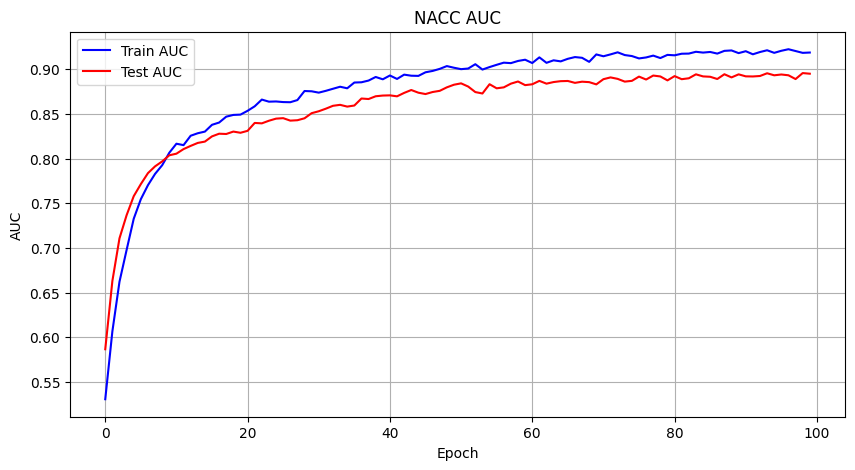

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("NACC AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

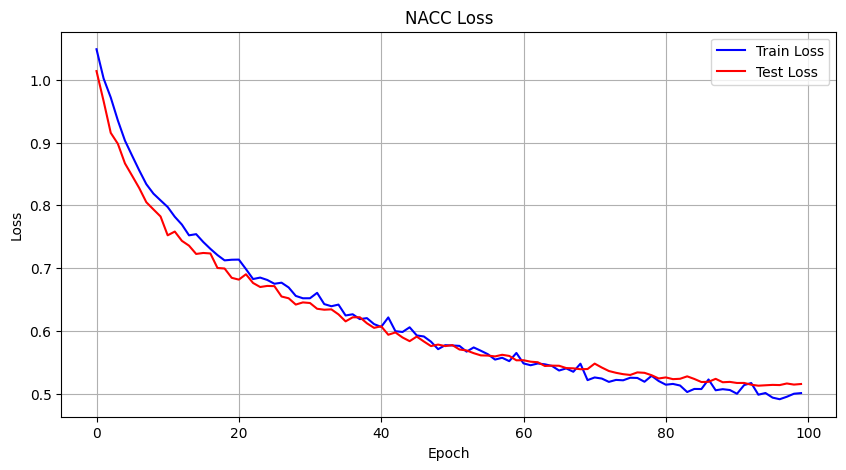

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("NACC Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()